## Notebook just for generating visuals I'll use in my final paper to explain how some models or preprocessing works

In [5]:
import sys, warnings, importlib
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import utils
importlib.reload(utils)
from utils import load_tracking, draw_rink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

tracking = load_tracking('data/tracking.parquet')
print(f"Loaded {len(tracking):,} rows")

Loaded 8,401,602 rows


In [9]:
# --- Raw vs. Smoothed Skater Path: grab a real shift from shifts.parquet ---

shifts = pd.read_parquet('data/shifts.parquet')

def parse_mmss(s):
    try: m, sec = str(s).split(':'); return int(m)*60 + int(sec)
    except: return np.nan

shifts['shift_s'] = shifts['shift_length'].apply(parse_mmss)
shifts['start_s'] = shifts['start_clock'].apply(parse_mmss)
shifts['end_s']   = shifts['end_clock'].apply(parse_mmss)

# Pick a long shift (≥30s), skip goalies
long_shifts = shifts[
    (shifts['shift_s'] >= 30) &
    (shifts['Player_Id'] != 'Go') &
    (shifts['Player_Id'].str.isnumeric())
].reset_index(drop=True)

# Iterate to find one with actual tracking data
win = pd.DataFrame()
shift = None
for idx in range(len(long_shifts)):
    sh = long_shifts.iloc[idx]
    game_key = f"{sh['Date']} {sh['Home_Team']} @ {sh['Away_Team']}"
    mask = (
        (tracking['Game']                      == game_key) &
        (tracking['Period_int']                == sh['period']) &
        (tracking['Player Jersey Number'].astype(str) == str(sh['Player_Id'])) &
        (tracking['Clock_s']                   >= sh['end_s']) &
        (tracking['Clock_s']                   <= sh['start_s']) &
        (tracking['Player or Puck']            == 'Player')
    )
    candidate = tracking[mask].sort_values('frame_id')
    if len(candidate) >= 20:
        win = candidate.copy()
        shift = sh
        break

print(f"Shift: {shift['Date']}  {shift['Home_Team']} vs {shift['Away_Team']}")
print(f"  Player #{shift['Player_Id']}, Period {shift['period']}, {shift['start_clock']} → {shift['end_clock']}  ({shift['shift_length']})")
print(f"  Tracking rows found: {len(win)}")
print(f"  Path span: x=[{win['x'].min():.1f}, {win['x'].max():.1f}]  y=[{win['y'].min():.1f}, {win['y'].max():.1f}]")

Shift: 2025-10-11  Team D vs Team A
  Player #29, Period 1, 20:00 → 19:05  (00:55)
  Tracking rows found: 1499
  Path span: x=[-85.4, 79.3]  y=[-40.2, 42.6]


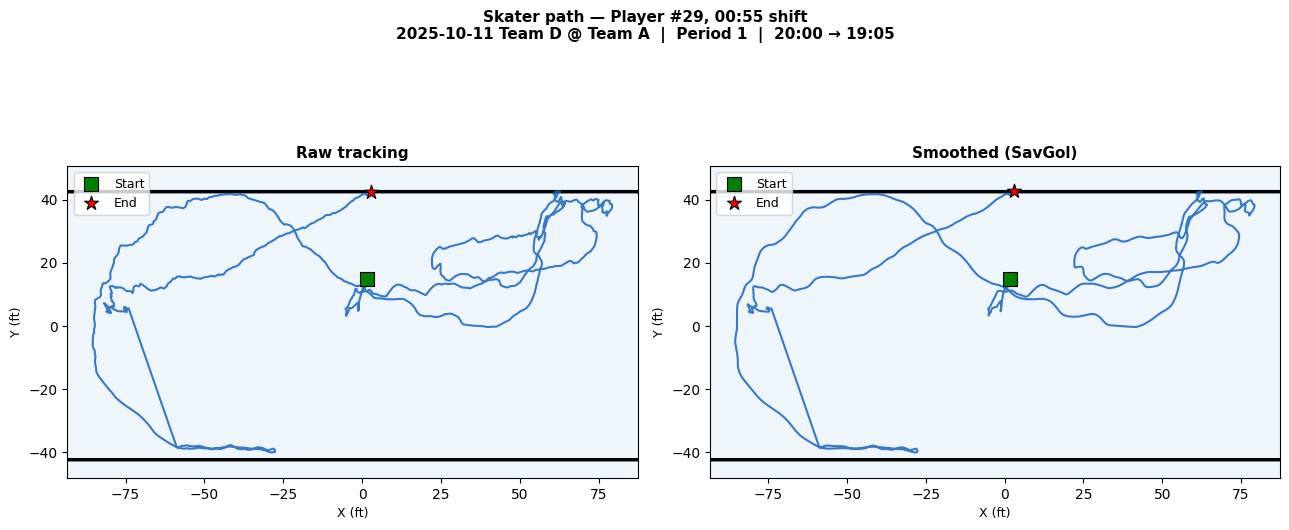

Saved → output/smoothing_comparison.png


In [12]:
# --- Plot: Raw vs. Smoothed path side by side ---

def draw_simple_rink(ax):
    """Boards outline only — no zone lines or circles."""
    from matplotlib.patches import FancyBboxPatch
    ax.set_facecolor('#eef6fc')
    ax.add_patch(FancyBboxPatch((-100, -42.5), 200, 85,
                                boxstyle="round,pad=0", linewidth=2.5,
                                edgecolor='black', facecolor='none', zorder=2))
    ax.set_aspect('equal')
    ax.set_xlabel('X (ft)', fontsize=9)
    ax.set_ylabel('Y (ft)', fontsize=9)

pad = 8
x_all = list(win['raw_x']) + list(win['x'])
y_all = list(win['raw_y']) + list(win['y'])
xlim = (min(x_all) - pad, max(x_all) + pad)
ylim = (min(y_all) - pad, max(y_all) + pad)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (xcol, ycol, title) in zip(axes, [
    ('raw_x', 'raw_y', 'Raw tracking'),
    ('x',     'y',     'Smoothed (SavGol)'),
]):
    draw_simple_rink(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=11, fontweight='bold')

    xs = win[xcol].values
    ys = win[ycol].values

    ax.plot(xs, ys, color='#1565C0', lw=1.5, zorder=4, alpha=0.85)

    ax.scatter(xs[0],  ys[0],  s=90,  marker='s', color='green',
               edgecolors='black', linewidth=0.8, zorder=6, label='Start')
    ax.scatter(xs[-1], ys[-1], s=110, marker='*', color='red',
               edgecolors='black', linewidth=0.8, zorder=6, label='End')
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle(
    f"Skater path — Player #{shift['Player_Id']}, {shift['shift_length']} shift\n"
    f"{game_key}  |  Period {shift['period']}  |  {shift['start_clock']} → {shift['end_clock']}",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/smoothing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → output/smoothing_comparison.png")

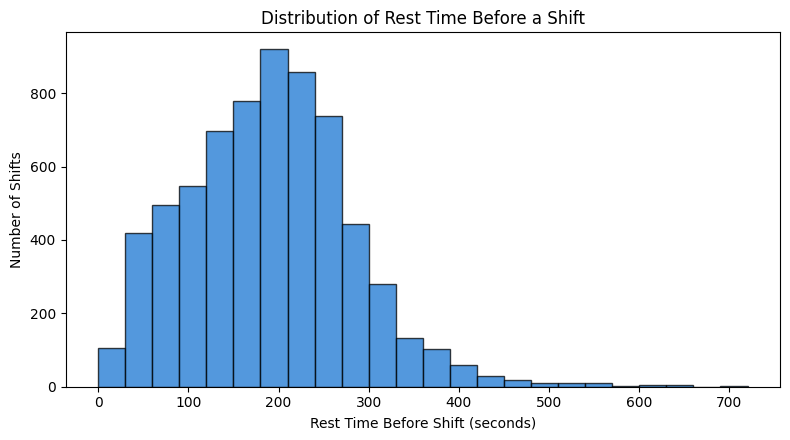

In [14]:
# --- Histogram: Rest time before a shift (30s bins, robust to column names) ---
shifts = pd.read_parquet('data/shifts.parquet')

def parse_mmss(s):
    try: m, sec = str(s).split(':'); return int(m)*60 + int(sec)
    except: return np.nan

shifts['shift_s'] = shifts['shift_length'].apply(parse_mmss)
shifts['start_s'] = shifts['start_clock'].apply(parse_mmss)
shifts['end_s']   = shifts['end_clock'].apply(parse_mmss)

# Only keep non-goalie, numeric player ids
shifts = shifts[(shifts['Player_Id'] != 'Go') & (shifts['Player_Id'].astype(str).str.isnumeric())].copy()

# Use available columns for grouping
shifts = shifts.sort_values(['Date', 'Home_Team', 'Away_Team', 'period', 'Player_Id', 'start_s'])
shifts['rest_time_s'] = shifts.groupby(['Date', 'Home_Team', 'Away_Team', 'period', 'Player_Id'])['end_s'].shift(1)
shifts['rest_time_s'] = shifts['start_s'] - shifts['rest_time_s']
shifts['rest_time_s'] = shifts['rest_time_s'].clip(lower=0)

# Remove first shifts (rest_time_s is NaN or zero)
rest_times = shifts['rest_time_s'].dropna()

plt.figure(figsize=(8, 4.5))
bins = np.arange(0, rest_times.max() + 30, 30)
plt.hist(rest_times, bins=bins, color='#1976D2', edgecolor='black', alpha=0.75)
plt.xlabel('Rest Time Before Shift (seconds)')
plt.ylabel('Number of Shifts')
plt.title('Distribution of Rest Time Before a Shift')
plt.tight_layout()
plt.show()